<a href="https://colab.research.google.com/github/zacw-243L/BAD-APPLE/blob/main/Bad_Apple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# First, upload the video:
from google.colab import files

uploaded = files.upload()

Saving bad-apple.mp4 to bad-apple.mp4


In [2]:
# Then install/import what we need:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Video, display

In [4]:
# Now define the 2-bit conversion.
def to_2bit(frame):
    # Convert video frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Convert 0-255 grayscale into four levels:
    # 0, 1, 2, 3
    two_bit = gray // 64

    return two_bit

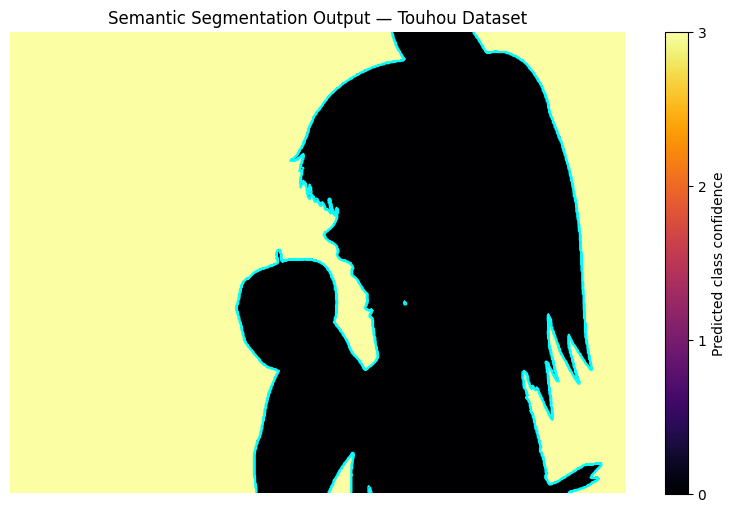

In [19]:
video_path = "bad-apple.mp4"

cap = cv2.VideoCapture(video_path)

# Skip to frame 300 to bypass the black introduction
target_frame = 300
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)

success, frame = cap.read()
cap.release()

if not success:
    print(f"Error: Could not read frame {target_frame} from the video.")
else:
    two_bit = to_2bit(frame)

    plt.figure(figsize=(10, 6))
    plt.imshow(
        two_bit,
        cmap="inferno",
        vmin=0,
        vmax=3,
        interpolation="nearest"
    )
    plt.colorbar( ticks=[0, 1, 2, 3], label="Predicted class confidence")
    plt.title("Semantic Segmentation Output — Touhou Dataset")
    # Specify a highly visible color (like 'cyan') for the contour lines
    plt.contour( two_bit, levels=[0.5, 1.5, 2.5], colors="cyan", linewidths=1.0 )
    plt.axis("off")
    plt.show()

In [22]:
# Route to full animation
video_path = "bad_apple.mp4"
output_path = "bad_apple_2bit_heatmap.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS:", fps)
print("Resolution:", width, "x", height)

# Now define four explicit heat-map colors:
# OpenCV uses BGR rather than RGB

heat_colors = np.array([
    [0,   0,   0],     # level 0: black
    [70,  0, 120],     # level 1: dark red/purple
    [0, 100, 255],     # level 2: orange
    [0, 255, 255],     # level 3: yellow
], dtype=np.uint8)

FPS: 0.0
Resolution: 0 x 0


In [23]:
# process the whole video:
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

i = 0

while True:
    success, frame = cap.read()

    if not success:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 256 possible values -> 4 possible values
    two_bit = gray // 64

    # Replace each value with its corresponding heat-map color
    heat_frame = heat_colors[two_bit]

    writer.write(heat_frame)

    i += 1

    if i % 500 == 0:
        print(f"{i}/{frame_count} frames")

cap.release()
writer.release()

print("Finished:", output_path)

Finished: bad_apple_2bit_heatmap.mp4


In [24]:
# Then play it directly inside Colab:

display(
    Video(
        output_path,
        embed=True,
        width=800
    )
)